[ 6153.87369124  3757.28112313 19801.13022094]
0.00063079
[ 3.88180199  2.37005536 12.49035493]
F1_array shape: (3,)


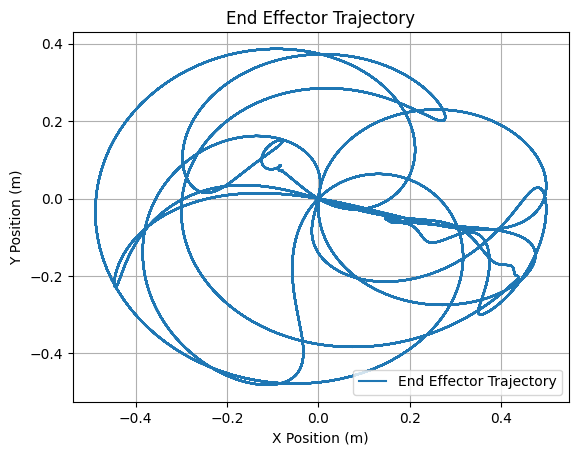

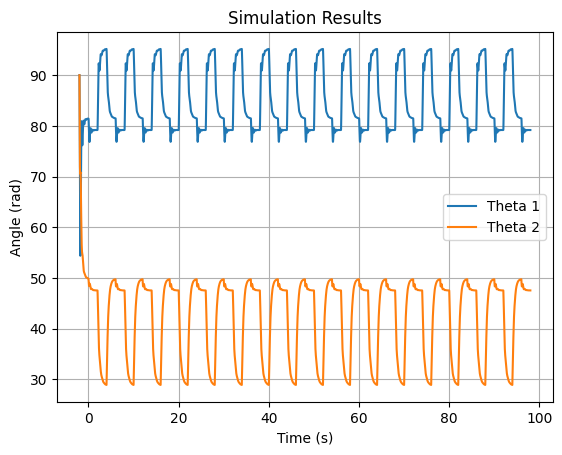

In [5]:
import mujoco
import datetime
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time

path = "../models/v2_4/urdf/dog2_4singleLeg_realconstrast.xml"

ExpName = f"AtoB_realsim_constrast_{datetime.datetime.now().strftime('%Y%m%d%H%M%S')}"
m = mujoco.MjModel.from_xml_path(path)
d = mujoco.MjData(m)

RB_BAA_SlideJoint_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_BAA_SlideJoint")
RB_BAA_FM_SlideJoint_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_BAA_FM_SlideJoint")
RB_MAA_SlideJoint_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_MAA_SlideJoint")
RB_MAA_FM_SlideJoint_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_MAA_FM_SlideJoint")
RB_shoulder_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_shoulder")
RB_Elbow_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_Elbow")

# Tools: 计算长度偏置（初始长度-原长）
def l_calulator(theta_1, theta_2):
    a_1 = 0.25
    a_2 = 0.25
    b_1 = 0.21213
    b_2 = 0.1
    d_1 = 0.06
    d_2 = 0.10

    # 角度参数 (度转弧度)
    beta_1 = 8.13 / 180 * np.pi
    beta_2 = 30 / 180 * np.pi

    A_x_O = d_1
    A_y_O = 0

    B_x_O = -d_2
    B_y_O = 0

    C_x_O = b_1 * np.cos(theta_1 - beta_1)
    C_y_O = b_1 * np.sin(theta_1 - beta_1)

    D_x_O = a_1 * np.cos(theta_1) + b_2 * np.cos(theta_1 + theta_2 + beta_2)
    D_y_O = a_1 * np.sin(theta_1) + b_2 * np.sin(theta_1 + theta_2 + beta_2)

    # 计算长度 l1 和 l2
    l_1 = np.sqrt((A_x_O - C_x_O)**2 + (A_y_O - C_y_O)**2)
    l_2 = np.sqrt((B_x_O - D_x_O)**2 + (B_y_O - D_y_O)**2)

    return l_1, l_2

# Tools: 计算驱动器设置初始偏置 (geom 模型)
def bias_calculator(l_10, l_20):
  l_1, l_2 = l_calulator(math.pi/2, math.pi/2)
  l1_rel = l_10 - l_1
  l2_rel = l_20 - l_2
  return l1_rel/2, l2_rel/2


P1_array = np.array([6.153873691241822, 3.757281123127819, 19.801130220938756])*1000
P2_array = np.array([2.7282463188213035, 7.2611504152265525, 8.519687913683074])*1000

viewer_flag = 0

def run_single_experiment(params, P1_array=P1_array, P2_array=P2_array, time_exp = 100, time_step = 2):
    """
    单次实验运行函数
    :param params: 包含(damping_MAA, damping_BAA, exp_id)的元组
    """
    try:
        stiffness_MAA, stiffness_BAA, l10, l20, damping_MAA, damping_BAA, s1, s2, c1_thigh, c2_calf = params
        
        m = mujoco.MjModel.from_xml_path(path)
        d = mujoco.MjData(m)
        print(P1_array)
        print(s1)

        F1_array = P1_array * s1
        F2_array = P2_array * s2
        print(F1_array)
        print(f"F1_array shape: {F1_array.shape}")

        # 设置刚度和阻尼
        for joint_id, stiffness, damping in zip(
            [RB_BAA_SlideJoint_id, RB_BAA_FM_SlideJoint_id, RB_MAA_SlideJoint_id, RB_MAA_FM_SlideJoint_id],
            [stiffness_BAA, stiffness_BAA, stiffness_MAA, stiffness_MAA],
            [damping_BAA, damping_BAA, damping_MAA, damping_MAA]
        ):
            m.jnt_stiffness[joint_id] = stiffness * 2
            m.dof_damping[joint_id] = damping * 2

        MAA_bias, BAA_bias = bias_calculator(l10, l20)
        for joint_id, bias in zip(
            [RB_BAA_SlideJoint_id, RB_BAA_FM_SlideJoint_id, RB_MAA_SlideJoint_id, RB_MAA_FM_SlideJoint_id],
            [BAA_bias, BAA_bias, MAA_bias, MAA_bias]
        ):
            m.qpos_spring[joint_id] = bias

        m.dof_damping[RB_shoulder_id] = c1_thigh
        m.dof_damping[RB_Elbow_id] = c2_calf

        d.ctrl = np.zeros_like(d.ctrl)
        mujoco.mj_step(m, d)

        # Experiment Settings
        ExpResultList = []
        

        start = time.time() if viewer_flag else d.time
        i = 0
        try:
            # if viewer_flag:
            #   with mujoco.viewer.launch_passive(m, d) as viewer:
                while (d.time - start) < time_exp:  # viewer.is_running() and
                    step_time = time.time() if viewer_flag else d.time

                    i = int((d.time - start)//2)
                    d.ctrl[:2] = F1_array[i%3]
                    d.ctrl[2:] = F2_array[i%3]
                    # elif time_step <= elapsed_time < time_exp:  # 稳定时间
                    #     d.ctrl[:] = 0  # 同时将所有控制信号置为0

                    # Trick: 由于实际数据稳定，所以这里只记录10s后的模拟数据，如果开始不收敛一定10s后的误差也很大
                    Position = np.array(d.qpos)
                    res = np.hstack((d.time, Position))
                    ExpResultList.append(res)

                    mujoco.mj_step(m, d)  # update!
                    if viewer_flag:
                      # 获取物理状态的更改，应用扰动，从GUI更新选项。
                    #   viewer.sync()   # TODO
                      # 粗略的计时，相对于挂钟会有漂移。
                      time_until_next_step = m.opt.timestep - (time.time() - step_time)
                      if time_until_next_step > 0:
                        time.sleep(time_until_next_step)

        # # 按住ctrl C退出循环
        except KeyboardInterrupt:
            pass
        
        # data process
        result_array = np.array(ExpResultList)
        time_sim = result_array[:,0]-time_step
        theta1_sim = (result_array[:,1]+math.pi/2)*180/np.pi
        theta2_sim = (result_array[:,2]+math.pi/2)*180/np.pi
        return time_sim, theta1_sim, theta2_sim
    
    except Exception as e:
        print(f"Error: {e}")
        raise e
    

k1 = 385.1225
k2 = 335.4172
l10 = 0.1862
l20 = 0.2709
c1 = 24.1515
c2 = 10.3101
s1 = 0.00063079
s2 = 0.00060325
c1_thigh = 4.9746
c2_calf = 0.3958
para = [k1, k2, l10, l20, c1, c2, s1, s2, c1_thigh, c2_calf]

time_sim, theta1_sim, theta2_sim = run_single_experiment(para, P1_array, P2_array, time_exp=100, time_step=2)

a_1 = 0.25
a_2 = 0.25
x_pos = a_1*np.cos(theta1_sim) + a_2*np.cos(theta1_sim + theta2_sim)
y_pos = a_1*np.sin(theta1_sim) + a_2*np.sin(theta1_sim + theta2_sim)
# Plotting the results
plt.figure()
slice_start = 5000
plt.plot(x_pos[slice_start:], y_pos[slice_start:], label='End Effector Trajectory')
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.title('End Effector Trajectory')
plt.legend()
plt.grid()


plt.figure()
plt.plot(time_sim, theta1_sim, label='Theta 1')
plt.plot(time_sim, theta2_sim, label='Theta 2')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.title('Simulation Results')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# 绘制轨迹